# 01. EDA & Preprocessing

이 노트북은 `src/preprocessing.py`, `src/train.py`, `src/inference.py`, `src/monitor.py`, `tests/test_pipeline.py`를 기준으로 데이터 로드, 탐색적 분석, 전처리 검증을 재현합니다.

## 목표
- 원본 UCI heart disease 파일들을 병합하는 방식을 확인합니다.
- `load_data()`가 수행하는 중복 제거, 컬럼 제거, 타깃 이진화를 재현합니다.
- 연속형/범주형 변수의 분포와 결측 현황을 확인합니다.
- 연속형 변수별 `IQR` 기준 이상치 개수를 계산합니다.
- `build_pipeline()` 출력이 결정론적이며 결측이 없음을 검증합니다.
- 이후 `train.py`, `inference.py`, `monitor.py`에서 사용하는 입력 형식을 준비합니다.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from pandas.testing import assert_frame_equal, assert_series_equal
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent
elif not (BASE_DIR / "src").exists() and (BASE_DIR.parent / "src").exists():
    BASE_DIR = BASE_DIR.parent

sys.path.append(str(BASE_DIR / "src"))

from preprocessing import (
    RAW_FILES,
    COLUMN_NAMES,
    DROP_COLS,
    TARGET_COL,
    FEATURE_COLS,
    CONTINUOUS_COLS,
    CATEGORICAL_COLS,
    VALID_RANGES,
    load_data,
    build_pipeline,
    validate_input_ranges,
)

DATA_DIR = BASE_DIR / "data"
RANDOM_STATE = 42
TEST_SIZE = 0.2

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")


BASE_DIR: C:\Users\김근호\OneDrive\바탕 화면\cardiocare
DATA_DIR: C:\Users\김근호\OneDrive\바탕 화면\cardiocare\data


## 1. 원본 데이터 로드

`preprocessing.py`는 네 개의 processed 데이터 파일을 읽어서 하나의 데이터프레임으로 합칩니다. 먼저 원본 병합 상태를 확인합니다.


In [2]:
def load_raw_dataframe(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    frames = []
    for source_name, filename in RAW_FILES.items():
        file_path = data_dir / filename
        df_part = pd.read_csv(file_path, header=None, names=COLUMN_NAMES, na_values="?")
        df_part["source"] = source_name
        frames.append(df_part)
    return pd.concat(frames, ignore_index=True)

file_summary = pd.DataFrame(
    [
        {
            "source": source_name,
            "file_name": filename,
            "exists": (DATA_DIR / filename).exists(),
            "file_size_bytes": (DATA_DIR / filename).stat().st_size if (DATA_DIR / filename).exists() else np.nan,
        }
        for source_name, filename in RAW_FILES.items()
    ]
)

raw_df = load_raw_dataframe(DATA_DIR)

display(file_summary)
print(f"Raw dataframe shape: {raw_df.shape}")
raw_df.head()


,source,file_name,exists,file_size_bytes
0,cleveland,processed.cleveland.data,True,18461
1,hungarian,processed.hungarian.data,True,10263
2,switzerland,processed.switzerland.data,True,4109
3,va,processed.va.data,True,6737


Raw dataframe shape: (920, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,0,cleveland
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,2,cleveland
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,1,cleveland
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,0,cleveland
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,0,cleveland


In [3]:
raw_profile = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "missing_count": raw_df.isna().sum(),
        "missing_ratio_pct": (raw_df.isna().mean() * 100).round(2),
    }
)

display(raw_profile.sort_values(["missing_count", "dtype"], ascending=[False, True]))
print(f"Duplicated rows in raw dataframe: {raw_df.duplicated().sum()}")
print("\nRaw target distribution before binarization")
display(raw_df[TARGET_COL].value_counts(dropna=False).sort_index().to_frame("count"))


,dtype,missing_count,missing_ratio_pct
ca,float64,611,66.410
thal,float64,486,52.830
slope,float64,309,33.590
fbs,float64,90,9.780
oldpeak,float64,62,6.740
trestbps,float64,59,6.410
thalach,float64,55,5.980
exang,float64,55,5.980
chol,float64,30,3.260
restecg,float64,2,0.220


Duplicated rows in raw dataframe: 2

Raw target distribution before binarization


,count
target,
0,411
1,265
2,109
3,107
4,28


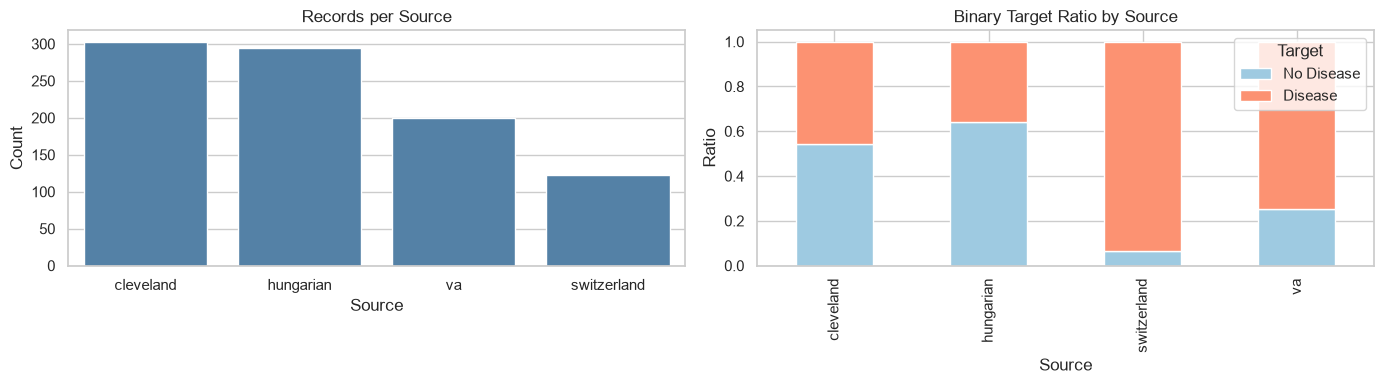

In [4]:
binary_target_for_eda = (raw_df[TARGET_COL] > 0).astype(int)
source_target_ratio = pd.crosstab(raw_df["source"], binary_target_for_eda, normalize="index")
source_target_ratio = source_target_ratio.rename(columns={0: "No Disease", 1: "Disease"})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=raw_df, x="source", order=raw_df["source"].value_counts().index, color="steelblue", ax=axes[0])
axes[0].set_title("Records per Source")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Count")

source_target_ratio.plot(kind="bar", stacked=True, ax=axes[1], color=["#9ecae1", "#fc9272"])
axes[1].set_title("Binary Target Ratio by Source")
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Ratio")
axes[1].legend(title="Target", loc="upper right")

plt.tight_layout()
plt.show()


## 2. `preprocessing.py` 로직 재현

이 단계에서는 실제 함수와 동일하게 중복 제거, 불필요 컬럼 제거, 타깃 이진화를 수행하고 `load_data()` 결과와 일치하는지 확인합니다.


In [5]:
eda_df = raw_df.drop_duplicates().copy()
cols_to_drop = [col for col in DROP_COLS if col in eda_df.columns]

clean_df = eda_df.drop(columns=cols_to_drop).copy()
clean_df[TARGET_COL] = (clean_df[TARGET_COL] > 0).astype(int)
clean_df = clean_df.dropna(subset=[TARGET_COL])

X, y = load_data(DATA_DIR)
project_df = X.copy()
project_df[TARGET_COL] = y.values

assert list(X.columns) == FEATURE_COLS
assert_frame_equal(clean_df[FEATURE_COLS].reset_index(drop=True), X.reset_index(drop=True))
assert_series_equal(clean_df[TARGET_COL].reset_index(drop=True), y.reset_index(drop=True), check_names=False)

print(f"Columns dropped: {cols_to_drop}")
print(f"Modeling dataframe shape: {project_df.shape}")
project_df.head()


2026-06-19 15:06:24 - INFO - Loading data from C:\Users\김근호\OneDrive\바탕 화면\cardiocare\data


2026-06-19 15:06:24 - INFO - Loaded cleveland with shape (303, 15)


2026-06-19 15:06:24 - INFO - Loaded hungarian with shape (294, 15)


2026-06-19 15:06:24 - INFO - Loaded switzerland with shape (123, 15)


2026-06-19 15:06:24 - INFO - Loaded va with shape (200, 15)


2026-06-19 15:06:24 - INFO - Combined data shape: (920, 15)


2026-06-19 15:06:24 - INFO - Dropped 2 duplicate rows


2026-06-19 15:06:24 - INFO - Dropped columns: ['ca', 'thal', 'slope', 'source']


Columns dropped: ['ca', 'thal', 'slope', 'source']
Modeling dataframe shape: (918, 11)


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,target
0,63.000,145.000,233.000,150.000,2.300,1.000,1.000,1.000,2.000,0.000,0
1,67.000,160.000,286.000,108.000,1.500,1.000,4.000,0.000,2.000,1.000,1
2,67.000,120.000,229.000,129.000,2.600,1.000,4.000,0.000,2.000,1.000,1
3,37.000,130.000,250.000,187.000,3.500,1.000,3.000,0.000,0.000,0.000,0
4,41.000,130.000,204.000,172.000,1.400,0.000,2.000,0.000,2.000,0.000,0


In [6]:
display(project_df[CONTINUOUS_COLS].describe().T)

class_ratio = (
    project_df[TARGET_COL]
    .value_counts(normalize=True)
    .sort_index()
    .rename(index={0: "No Disease", 1: "Disease"})
    .mul(100)
    .round(2)
    .to_frame("ratio_pct")
)
missing_after_load = X.isna().sum().sort_values(ascending=False).to_frame("missing_count")

display(class_ratio)
display(missing_after_load)


,count,mean,std,min,25%,50%,75%,max
age,918.000,53.511,9.433,28.000,47.000,54.000,60.000,77.000
trestbps,859.000,132.137,19.064,0.000,120.000,130.000,140.000,200.000
chol,889.000,199.108,110.841,0.000,175.000,223.000,268.000,603.000
thalach,863.000,137.542,25.937,60.000,120.000,140.000,157.000,202.000
oldpeak,856.000,0.881,1.092,-2.600,0.000,0.500,1.500,6.200


,ratio_pct
target,
No Disease,44.660
Disease,55.340


,missing_count
fbs,90
oldpeak,62
trestbps,59
exang,55
thalach,55
chol,29
restecg,2
age,0
sex,0
cp,0


2026-06-19 15:06:24 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:24 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:24 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:24 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:24 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:25 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:25 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:25 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:25 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:25 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


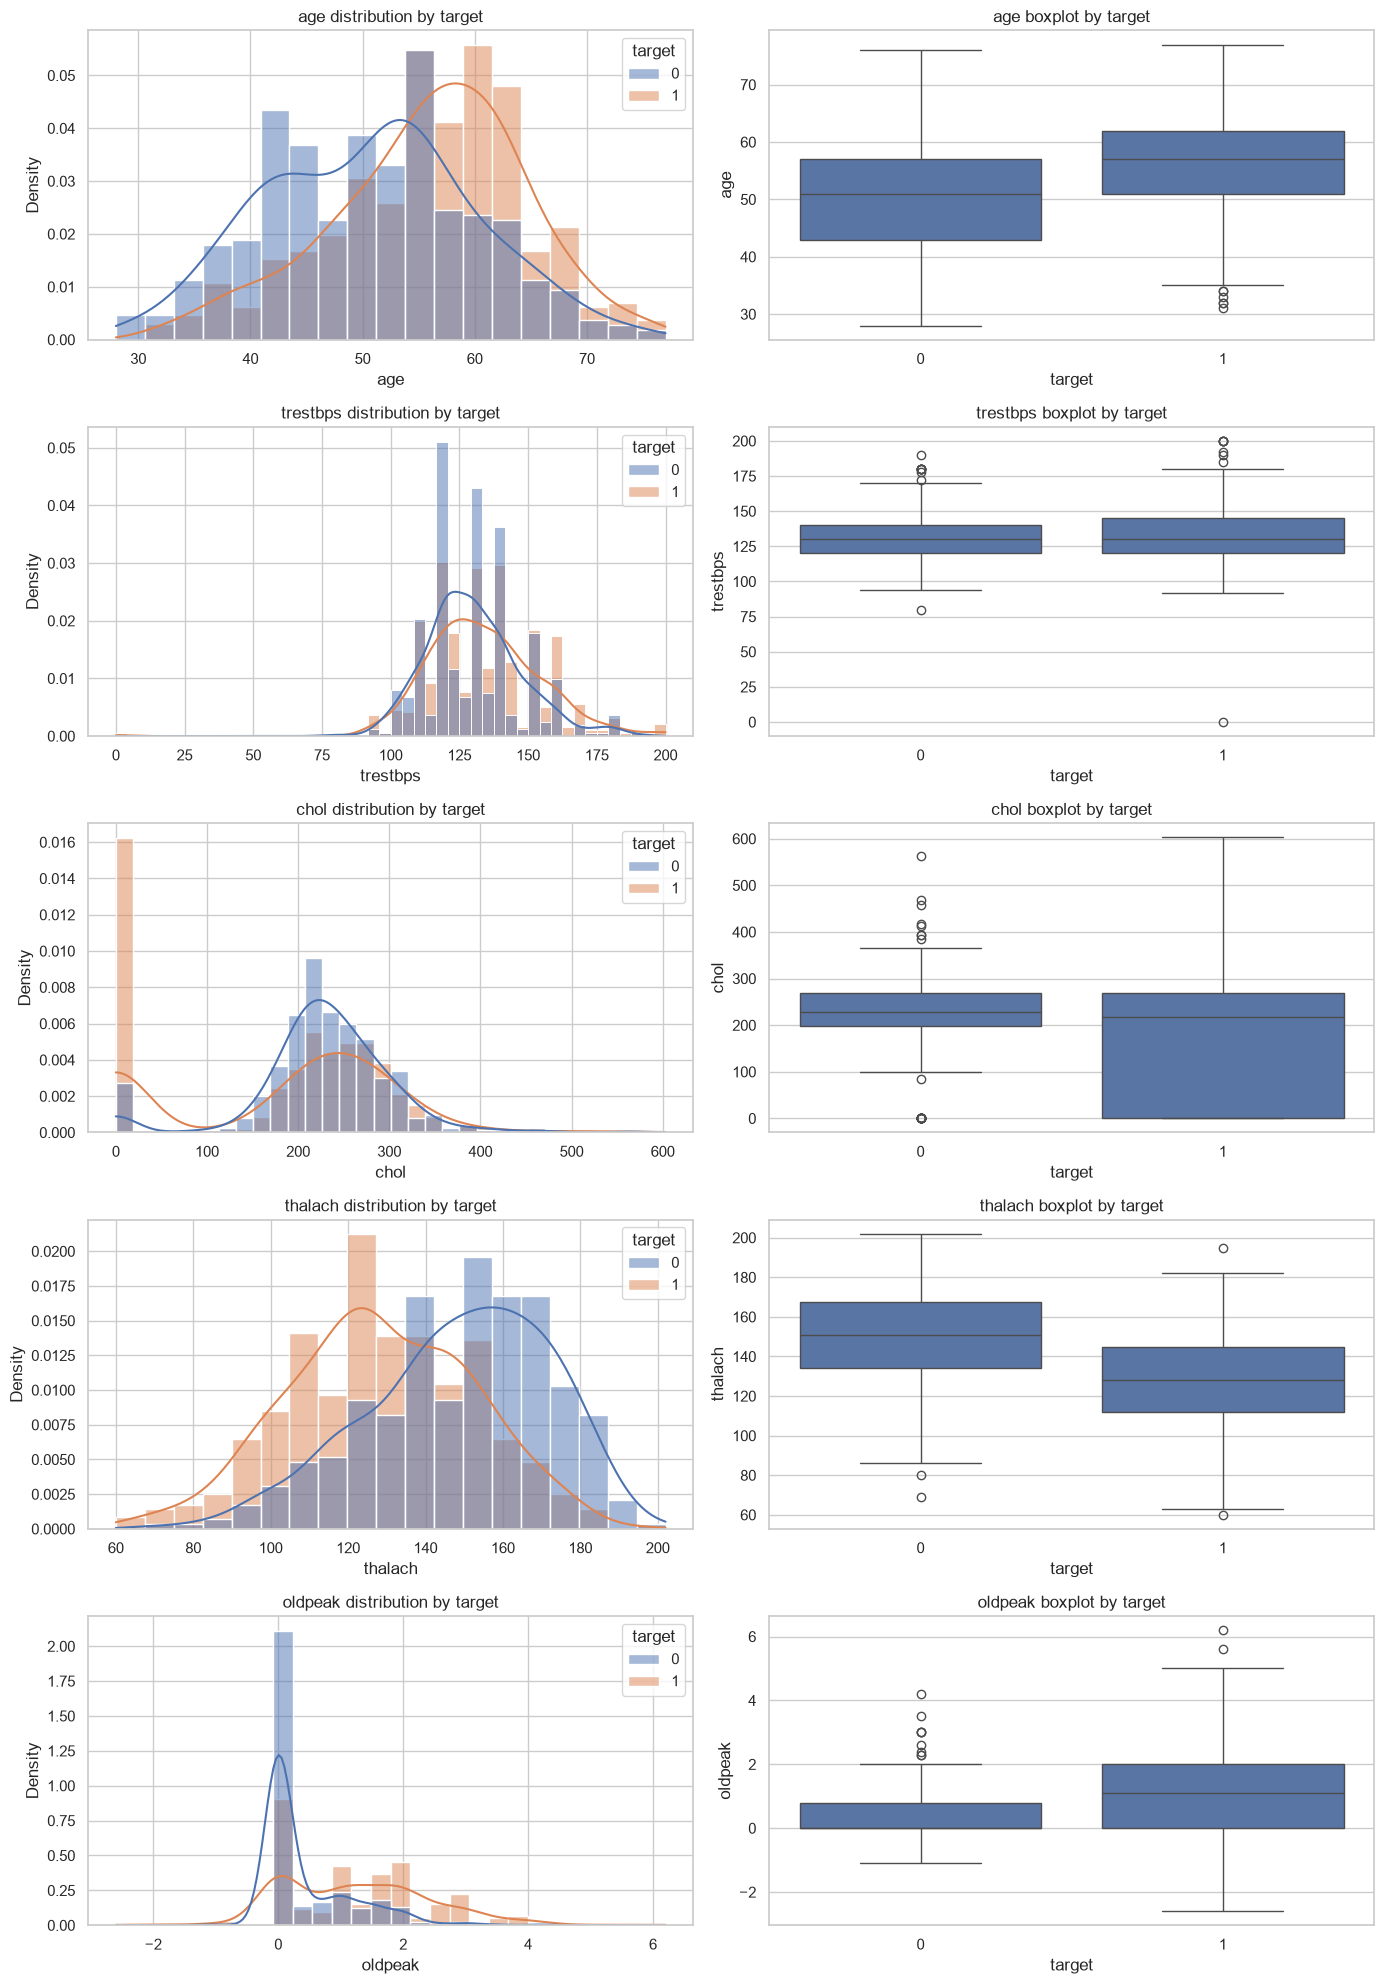

In [7]:
fig, axes = plt.subplots(len(CONTINUOUS_COLS), 2, figsize=(14, 4 * len(CONTINUOUS_COLS)))

for idx, col in enumerate(CONTINUOUS_COLS):
    sns.histplot(data=project_df, x=col, hue=TARGET_COL, kde=True, stat="density", common_norm=False, ax=axes[idx, 0])
    axes[idx, 0].set_title(f"{col} distribution by target")

    sns.boxplot(data=project_df, x=TARGET_COL, y=col, ax=axes[idx, 1])
    axes[idx, 1].set_title(f"{col} boxplot by target")

plt.tight_layout()
plt.show()


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_ratio_pct
2,chol,175.000,268.000,93.000,35.500,407.500,183,19.930
1,trestbps,120.000,140.000,20.000,90.000,170.000,28,3.050
4,oldpeak,0.000,1.500,1.500,-2.250,3.750,16,1.740
3,thalach,120.000,157.000,37.000,64.500,212.500,2,0.220
0,age,47.000,60.000,13.000,27.500,79.500,0,0.000


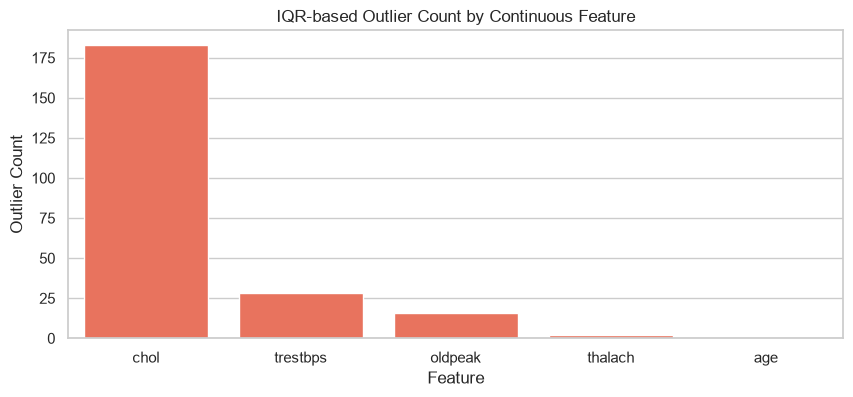

In [8]:
iqr_rows = []

for col in CONTINUOUS_COLS:
    series = project_df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    mask = (project_df[col] < lower_bound) | (project_df[col] > upper_bound)
    outlier_count = int(mask.sum())

    iqr_rows.append(
        {
            "feature": col,
            "q1": round(q1, 3),
            "q3": round(q3, 3),
            "iqr": round(iqr, 3),
            "lower_bound": round(lower_bound, 3),
            "upper_bound": round(upper_bound, 3),
            "outlier_count": outlier_count,
            "outlier_ratio_pct": round(outlier_count / len(project_df) * 100, 2),
        }
    )

iqr_outlier_summary = pd.DataFrame(iqr_rows).sort_values("outlier_count", ascending=False)
display(iqr_outlier_summary)

plt.figure(figsize=(10, 4))
sns.barplot(data=iqr_outlier_summary, x="feature", y="outlier_count", color="tomato")
plt.title("IQR-based Outlier Count by Continuous Feature")
plt.xlabel("Feature")
plt.ylabel("Outlier Count")
plt.show()


2026-06-19 15:06:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-19 15:06:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


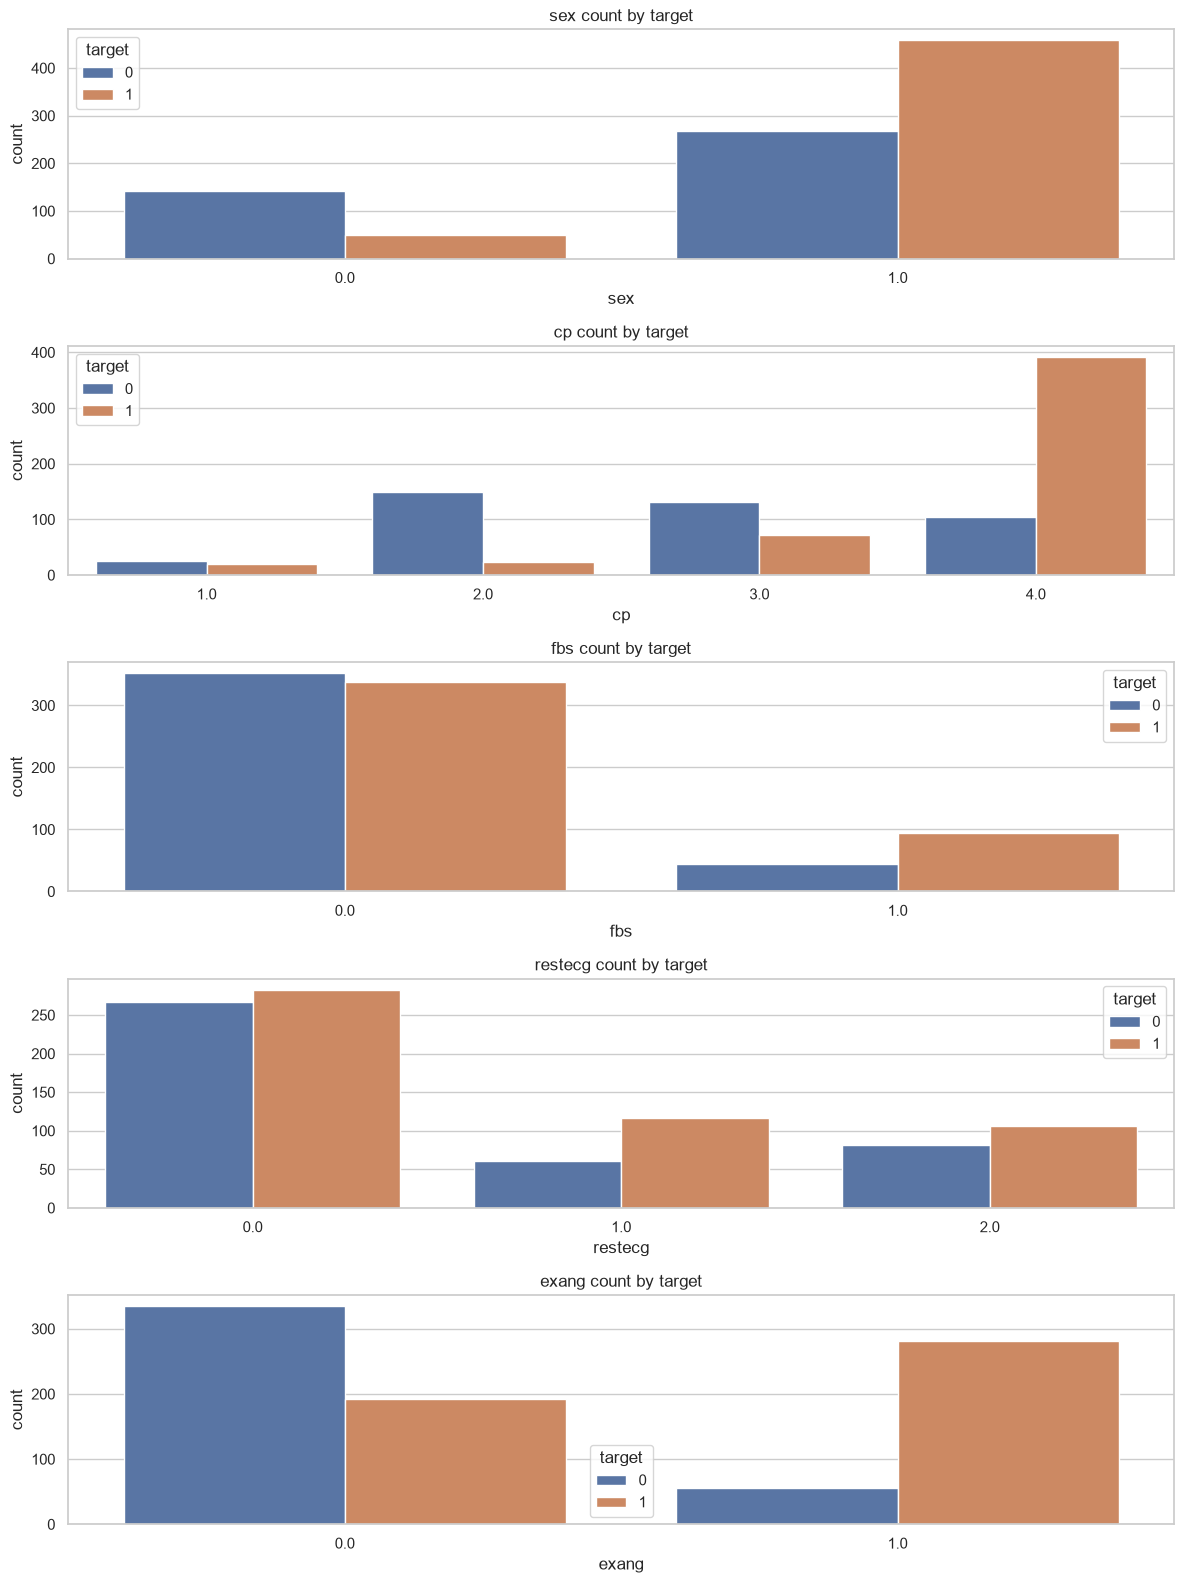

In [9]:
fig, axes = plt.subplots(len(CATEGORICAL_COLS), 1, figsize=(12, 3.2 * len(CATEGORICAL_COLS)))
if len(CATEGORICAL_COLS) == 1:
    axes = [axes]

for ax, col in zip(axes, CATEGORICAL_COLS):
    plot_df = project_df.groupby([col, TARGET_COL]).size().reset_index(name="count")
    sns.barplot(data=plot_df, x=col, y="count", hue=TARGET_COL, ax=ax)
    ax.set_title(f"{col} count by target")
    ax.set_xlabel(col)
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()


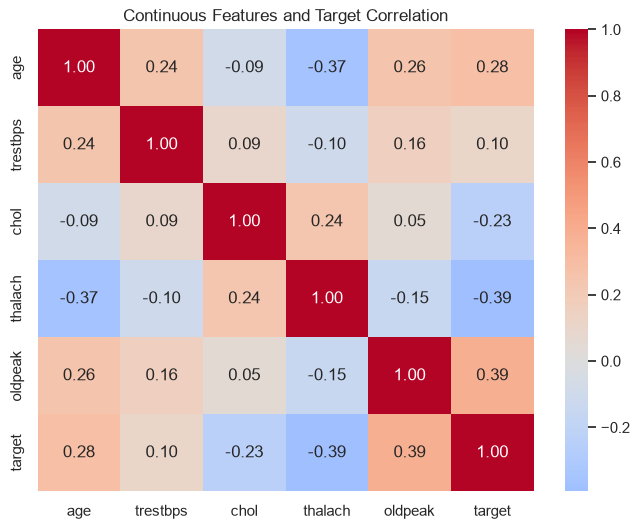

In [10]:
corr_df = project_df[CONTINUOUS_COLS + [TARGET_COL]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Continuous Features and Target Correlation")
plt.show()


## 3. 입력 검증과 전처리 파이프라인

`inference.py`는 임상 범위를 검사하고, `build_pipeline()`은 결측 대치와 스케일링/인코딩을 수행합니다. 테스트 코드에서 검증하는 조건도 여기서 같이 확인합니다.


In [11]:
range_summary = pd.DataFrame(
    [
        {
            "feature": feature,
            "min_allowed": min_allowed,
            "max_allowed": max_allowed,
            "observed_min": X[feature].min(),
            "observed_max": X[feature].max(),
        }
        for feature, (min_allowed, max_allowed) in VALID_RANGES.items()
        if feature in X.columns
    ]
)

sample_input = pd.read_csv(DATA_DIR / "sample_input.csv")
training_range_violations = validate_input_ranges(X)
sample_range_violations = validate_input_ranges(sample_input[FEATURE_COLS])

display(range_summary)
print(f"Training data range violations: {training_range_violations}")
print(f"sample_input.csv range violations: {sample_range_violations}")


,feature,min_allowed,max_allowed,observed_min,observed_max
0,age,1,120,28.000,77.000
1,trestbps,50,250,0.000,200.000
2,chol,0,600,0.000,603.000
3,thalach,50,250,60.000,202.000
4,oldpeak,0,10,-2.600,6.200
5,sex,0,1,0.000,1.000
6,cp,1,4,1.000,4.000
7,fbs,0,1,0.000,1.000
8,restecg,0,2,0.000,2.000
9,exang,0,1,0.000,1.000


Training data range violations: ['trestbps', 'chol', 'oldpeak']
sample_input.csv range violations: []


In [12]:
pipeline = build_pipeline()
X_transformed = pipeline.fit_transform(X)
transformed_columns = pipeline.named_steps["preprocessor"].get_feature_names_out()
transformed_df = pd.DataFrame(X_transformed, columns=transformed_columns, index=X.index)

print(pipeline)
print(f"Input shape: {X.shape}")
print(f"Transformed shape: {X_transformed.shape}")
transformed_df.head()


2026-06-19 15:06:29 - INFO - Building preprocessing pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalE

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang
0,1.007,0.705,0.304,0.490,1.366,1.000,0.000,1.000,2.000,0.000
1,1.431,1.519,0.790,-1.181,0.610,1.000,3.000,0.000,2.000,1.000
2,1.431,-0.651,0.267,-0.346,1.649,1.000,3.000,0.000,2.000,1.000
3,-1.751,-0.108,0.460,1.961,2.500,1.000,2.000,0.000,0.000,0.000
4,-1.327,-0.108,0.038,1.365,0.515,0.000,1.000,0.000,2.000,0.000


In [13]:
X_transformed_again = pipeline.transform(X)
second_pipeline = build_pipeline()
X_transformed_refit = second_pipeline.fit_transform(X)

assert X_transformed.shape == (len(X), len(FEATURE_COLS))
assert not np.isnan(X_transformed).any()
np.testing.assert_allclose(X_transformed, X_transformed_again)
np.testing.assert_allclose(X_transformed, X_transformed_refit)

print("Preprocessing checks passed:")
print("- output shape matches number of input features")
print("- no missing values remain after preprocessing")
print("- transform output is deterministic")


2026-06-19 15:06:29 - INFO - Building preprocessing pipeline


Preprocessing checks passed:
- output shape matches number of input features
- no missing values remain after preprocessing
- transform output is deterministic


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "target_mean": [y_train.mean(), y_test.mean()],
    },
    index=["train", "test"],
)

display(split_summary)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train no disease: {(y_train == 0).sum()} | disease: {(y_train == 1).sum()}")
print(f"Test no disease: {(y_test == 0).sum()} | disease: {(y_test == 1).sum()}")


,rows,target_mean
train,734,0.553
test,184,0.554


Train shape: (734, 10), Test shape: (184, 10)
Train no disease: 328 | disease: 406
Test no disease: 82 | disease: 102


## 4. 다음 단계 정리

- `train.py`는 여기서 만든 전처리 결과 위에 `SelectFromModel`과 분류기를 붙여 학습합니다.
- `inference.py`는 `FEATURE_COLS` 순서와 `VALID_RANGES`를 그대로 사용해 입력을 검증합니다.
- `monitor.py`는 `CONTINUOUS_COLS`에 대해 KS 검정 기반 드리프트를 계산하고 성능 시계열을 저장합니다.
- 따라서 이 노트북의 핵심 산출물은 데이터 구조 이해, 결측/범위 확인, 전처리 검증입니다.


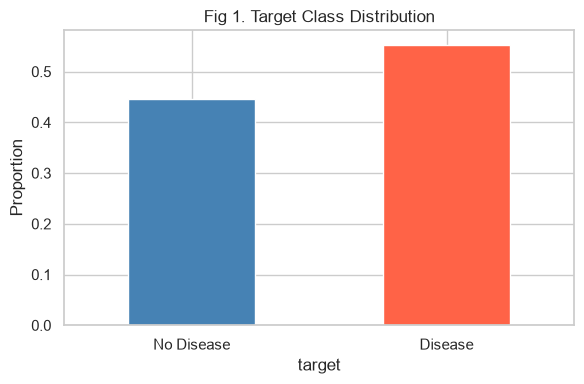

,컬럼,결측률(%)
0,ca,66.410
1,thal,52.830
2,slope,33.590
3,fbs,9.780
4,oldpeak,6.740


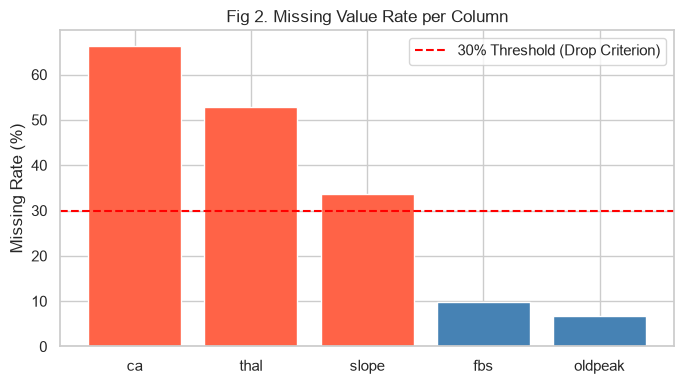

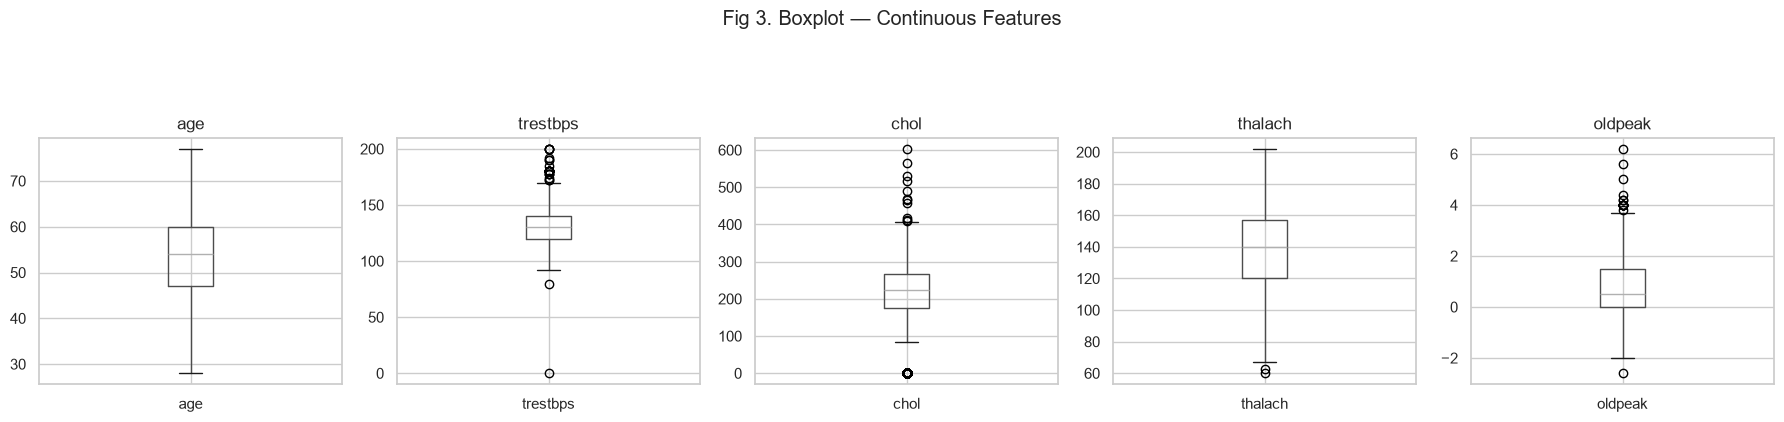

In [15]:
import matplotlib.pyplot as plt

FIG_DIR = BASE_DIR / "notebooks"

# 그림 1: 클래스 분포
fig, ax = plt.subplots(figsize=(6, 4))
y.value_counts(normalize=True).sort_index().rename({0: "No Disease", 1: "Disease"}).plot(
    kind="bar", color=["steelblue", "tomato"], ax=ax
)
ax.set_title("Fig 1. Target Class Distribution")
ax.set_ylabel("Proportion")
ax.set_xticklabels(["No Disease", "Disease"], rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_class_distribution.png", dpi=150)
plt.show()

# 그림 2: 결측값
raw_missing = (
    raw_df[["ca", "thal", "slope", "fbs", "oldpeak"]]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)
raw_missing.columns = ["컬럼", "결측률(%)"]
display(raw_missing)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    raw_missing["컬럼"],
    raw_missing["결측률(%)"],
    color=["tomato", "tomato", "tomato", "steelblue", "steelblue"],
)
ax.axhline(30, color="red", linestyle="--", label="30% Threshold (Drop Criterion)")
ax.set_title("Fig 2. Missing Value Rate per Column")
ax.set_ylabel("Missing Rate (%)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_missing_values.png", dpi=150)
plt.show()

# 그림 3: 이상치
fig, axes = plt.subplots(1, len(CONTINUOUS_COLS), figsize=(18, 4))
for ax, col in zip(axes, CONTINUOUS_COLS):
    project_df.boxplot(column=col, ax=ax)
    ax.set_title(col)
fig.suptitle("Fig 3. Boxplot — Continuous Features", y=1.05)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(FIG_DIR / "fig3_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
